Load Layout Output

In [1]:
!pip install -q sentence-transformers
!pip install -q transformers
!pip install -q faiss-cpu
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 71.4 MB/s eta 0:00:00


In [2]:
import os
import json
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from transformers import AutoTokenizer
from transformers import AutoModel

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
ROOT = "/content/drive/MyDrive/5.SemanticMapping"

LAYOUT_JSON = "/content/drive/MyDrive/5.SemanticMapping/0_layoutlmv3_layout.json"

FAISS_DIR = os.path.join(ROOT, "faiss")

OUTPUT_DIR = os.path.join(ROOT, "semantic_output")

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
with open(LAYOUT_JSON, "r", encoding="utf-8") as f:

    layout = json.load(f)

print(len(layout))

2554


In [6]:
total_pages = len(layout)

pages_with_blocks = 0
pages_without_blocks = 0
total_blocks = 0

for page in layout.values():
    # Ensure 'page' is a dictionary and contains the 'blocks' key
    if not isinstance(page, dict) or "blocks" not in page:
        print(f"Warning: Skipping malformed page entry - expected dictionary with 'blocks' key, got type {type(page)} or missing 'blocks'. Value: {page}")
        continue

    n = len(page["blocks"])

    total_blocks += n

    if n == 0:
        pages_without_blocks += 1
    else:
        pages_with_blocks += 1

print(f"Total pages        : {total_pages}")
print(f"Pages with blocks  : {pages_with_blocks}")
print(f"Pages without text : {pages_without_blocks}")
print(f"Total blocks       : {total_blocks}")

Total pages        : 2554
Pages with blocks  : 2295
Pages without text : 259
Total blocks       : 14333


In [7]:
for k, v in layout.items():
    if isinstance(v, list):
        print(k)

In [8]:
for page_name, page in layout.items():

    if len(page["blocks"]) > 0:

        print(page_name)

        print(json.dumps(
            page["blocks"][0],
            indent=2,
            ensure_ascii=False
        ))

        break

bao_viet_holdings_2023_p002_jpg.rf.6d94b20408c83a64a3f18835cb476455.jpg
{
  "type": "figure",
  "labels": [
    "figure"
  ],
  "text": "VALUE",
  "bbox": [
    813,
    210,
    831,
    222
  ],
  "confidence": 0.5396943986415863,
  "num_lines": 1,
  "num_words": 1,
  "words": [
    {
      "text": "VALUE",
      "bbox": [
        813,
        210,
        831,
        222
      ],
      "label": "figure",
      "confidence": 0.5396943986415863,
      "cx": 822.0,
      "cy": 216.0
    }
  ]
}


Extract Text Blocks

In [9]:
print(type(layout))
print(layout.keys())

first_key = list(layout.keys())[0]

print(first_key)
print(type(layout[first_key]))
print(layout[first_key])

<class 'dict'>
dict_keys(['bao_viet_holdings_2023_p001_jpg.rf.71d1c226ae7691851a350307f0f6ae35.jpg', 'bao_viet_holdings_2023_p002_jpg.rf.6d94b20408c83a64a3f18835cb476455.jpg', 'bao_viet_holdings_2023_p003_jpg.rf.a7d217e31e6281ebc520bebb884f36ca.jpg', 'bao_viet_holdings_2023_p004_jpg.rf.b26c1222f8af3a825e48821d2cf07d76.jpg', 'bao_viet_holdings_2023_p005_jpg.rf.b14200e7e731cc77891a7edc07def6f0.jpg', 'bao_viet_holdings_2023_p006_jpg.rf.97574566c695a8d01271c0b95b93329c.jpg', 'bao_viet_holdings_2023_p007_jpg.rf.12a9fcdbf510dd714b0991b95368bb5c.jpg', 'bao_viet_holdings_2023_p008_jpg.rf.9f410c63773e026e0cd7be0966392872.jpg', 'bao_viet_holdings_2023_p009_jpg.rf.789c76f216fb004bd549c6124901a41a.jpg', 'bao_viet_holdings_2023_p010_jpg.rf.ac45010875cf924d826c974230ee67e4.jpg', 'bao_viet_holdings_2023_p011_jpg.rf.c3d71d260dce9482bb65f10f36ee808d.jpg', 'bao_viet_holdings_2023_p012_jpg.rf.832df685ba44bb8e5af870948b6e444f.jpg', 'bao_viet_holdings_2023_p013_jpg.rf.59243009c41ca44290f1e3f5e9b5bdb3.jpg',

In [10]:
print(type(layout))
print(type(next(iter(layout.values()))))

<class 'dict'>
<class 'dict'>


In [11]:
first_key = list(layout.keys())[0]

print(first_key)
print(layout[first_key])

bao_viet_holdings_2023_p001_jpg.rf.71d1c226ae7691851a350307f0f6ae35.jpg
{'page': 'bao_viet_holdings_2023_p001_jpg.rf.71d1c226ae7691851a350307f0f6ae35.jpg', 'num_words': 15, 'num_blocks': 0, 'block_summary': {}, 'blocks': []}


In [12]:
semantic_blocks = []

block_id = 0

for page_name, page in layout.items():
    # Ensure 'page' is a dictionary and contains the 'blocks' key
    if not isinstance(page, dict) or "blocks" not in page:
        print(f"Warning: Skipping malformed page entry for {page_name} - expected dictionary with 'blocks' key, got type {type(page)} or missing 'blocks'. Value: {page}")
        continue

    for block in page["blocks"]:

        if block["type"] not in ["text", "figure"]:
            continue

        if len(block["text"].strip()) < 10:
            continue

        semantic_blocks.append({

            "block_id": block_id,

            "page": page_name,

            "bbox": block["bbox"],

            "type": block["type"],

            "confidence": block["confidence"],

            "text": block["text"]

        })

        block_id += 1

print(len(semantic_blocks))

13236


ClimateBERT

In [13]:
MODEL_NAME = "climatebert/distilroberta-base-climate-f"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

model.eval()

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50500, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-5): 6 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout)

In [14]:
def encode(texts,
           batch_size=32):

    embeddings = []

    with torch.no_grad():

        for i in tqdm(range(0, len(texts), batch_size)):

            batch = texts[i:i+batch_size]

            inputs = tokenizer(

                batch,

                padding=True,

                truncation=True,

                max_length=512,

                return_tensors="pt"

            ).to(device)

            outputs = model(**inputs)

            emb = outputs.last_hidden_state.mean(dim=1)

            embeddings.append(

                emb.cpu().numpy()

            )

    return np.vstack(embeddings)

In [15]:
texts = [

    b["text"]

    for b in semantic_blocks

]

query_embeddings = encode(texts)

print(query_embeddings.shape)

100%|██████████| 414/414 [01:58<00:00,  3.48it/s]

(13236, 768)


Load ESG KB

In [16]:
index = faiss.read_index(

    os.path.join(

        FAISS_DIR,

        "esg.index"

    )
)

metadata = json.load(

    open(

        os.path.join(

            FAISS_DIR,

            "metadata.json"

        ),

        encoding="utf-8"

    )

)

print(index.ntotal)

3456


Semantic Retrieval

In [17]:
faiss.normalize_L2(query_embeddings)

TOP_K = 5

scores, ids = index.search(

    query_embeddings,

    TOP_K

)

In [18]:
for i in range(len(semantic_blocks)):

    matches = []

    for score, idx in zip(

        scores[i],

        ids[i]

    ):

        item = metadata[idx].copy()

        item["score"] = float(score)

        matches.append(item)

    semantic_blocks[i]["top_matches"] = matches

Semantic Label

In [19]:
for block in semantic_blocks:

    best = block["top_matches"][0]

    block["semantic_standard"] = best["standard"]

    block["semantic_document"] = best["document"]

    block["semantic_score"] = best["score"]

In [20]:
semantic_summary = {}

for block in semantic_blocks:

    key = block["semantic_standard"]

    semantic_summary[key] = semantic_summary.get(key,0)+1

semantic_summary

{'GRI 2': 214,
 'GRI 12': 8743,
 'ghg-protocol-revised': 1506,
 'GRI 11': 753,
 'GRI 13': 461,
 'GRI 103': 136,
 'GRI 205': 350,
 'GRI 14': 145,
 'GRI 102': 209,
 'GRI 3': 177,
 'GRI Standards Glossary 2025': 272,
 'GRI 306': 18,
 'GRI 303': 34,
 'GRI 401': 9,
 'GRI 407': 4,
 'GRI 409': 2,
 'GRI 406': 11,
 'GRI 207': 29,
 'GRI 305': 19,
 'GRI 403': 59,
 'GRI 1': 12,
 'GRI 402': 1,
 'GRI 404': 3,
 'GRI 101': 21,
 'GRI 413': 1,
 'GRI 202': 5,
 'GRI 201': 18,
 'GRI 206': 14,
 'GRI 410': 4,
 'GRI 204': 1,
 'GRI 411': 1,
 'GRI 405': 1,
 'GRI 302': 3}

Export

In [21]:
OUT_FILE = os.path.join(

    OUTPUT_DIR,

    "semantic_blocks.json"

)

with open(

    OUT_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        semantic_blocks,

        f,

        ensure_ascii=False,

        indent=2

    )

print(OUT_FILE)

/content/drive/MyDrive/5.SemanticMapping/semantic_output/semantic_blocks.json


Visualization

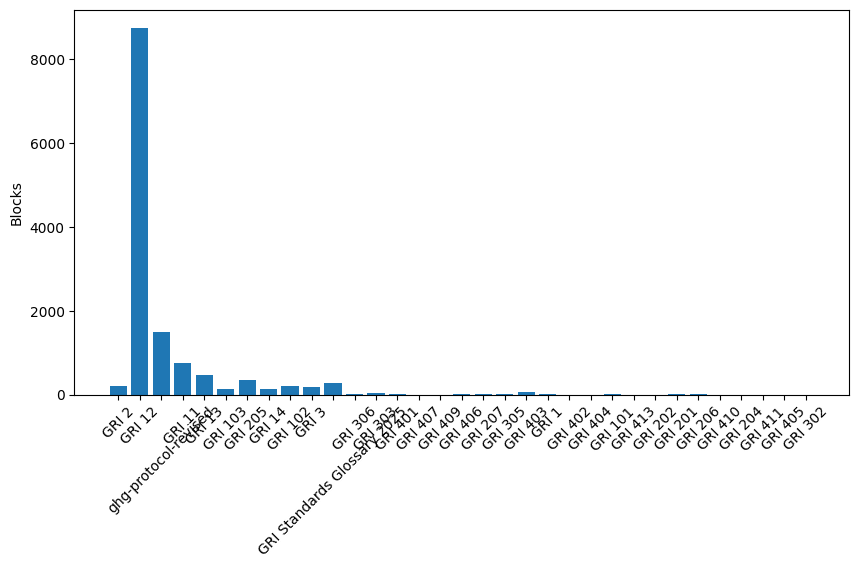

In [22]:
plt.figure(figsize=(10,5))

plt.bar(

    semantic_summary.keys(),

    semantic_summary.values()

)

plt.xticks(rotation=45)

plt.ylabel("Blocks")

plt.show()

In [23]:
semantic_blocks[0]

{'block_id': 0,
 'page': 'bao_viet_holdings_2023_p002_jpg.rf.6d94b20408c83a64a3f18835cb476455.jpg',
 'bbox': [851, 379, 960, 424],
 'type': 'figure',
 'confidence': 0.560416255146265,
 'text': 'Ggo0 APPRECIATE WHAT WE HAVE\nENKIRONMENTAL what we hold',
 'top_matches': [{'chunk_id': 2015,
   'document': 'GRI 2_ General Disclosures 2021',
   'standard': 'GRI 2',
   'page': 52,
   'local_chunk': 2,
   'num_words': 20,
   'text': '; modified Note: See Guidance to Disclosure 2-25 in GRI 2: General Disclosures 2021 for more information on ‘grievance mechanism’',
   'score': 0.839975893497467},
  {'chunk_id': 998,
   'document': 'GRI 13_ Agriculture Aquaculture and Fishing Sectors 2022 V1.1',
   'standard': 'GRI 13',
   'page': 24,
   'local_chunk': 2,
   'num_words': 21,
   'text': '. This information can support the reporting for additional sector disclosure 13.4.5. GRI 13: Agriculture, Aquaculture and Fishing Sectors 2022 V1.',
   'score': 0.8344203233718872},
  {'chunk_id': 2141,
   'docu